# Graph-Theoretic Node Ablation: FFL Motif Participation vs Structural Importance

This notebook demonstrates a graph-theoretic analysis of neural network attribution graphs from Neuronpedia. It tests whether nodes participating in overrepresented **Feed-Forward Loop (FFL/030T)** motif instances are disproportionately important to graph information flow.

**Method overview:**
1. **Load & prune** attribution graphs (keep top-percentile edges, filter by size)
2. **Enumerate FFL motifs** and compute Motif Participation Index (MPI) per node
3. **Classify nodes** into hubs (high MPI), participants, and non-FFL nodes
4. **Select matched controls** (degree-matched, attribution-matched, layer-matched, random)
5. **Ablate nodes** and measure 4 impact metrics (downstream attribution loss, path disruption, reachability loss, component fragmentation)
6. **Statistical analysis** — Wilcoxon tests, bootstrap CIs, dose-response correlations

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# python-igraph — NOT on Colab, always install
_pip('python-igraph==0.11.8')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import time

import igraph
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter4_graph_theoretic/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} attribution graph examples")
for ex in examples:
    print(f"  - {ex.get('metadata_slug','?')} (domain={ex.get('metadata_fold','?')})")

Loaded 3 attribution graph examples
  - m4-antonym-011-9a7d4704 (domain=antonym)
  - m4-arithmetic-016-d0c8069d (domain=arithmetic)
  - m4-code_completion-000-7016315e (domain=code_completion)


## Configuration

All tunable parameters. Start with minimum values for fast execution.

In [5]:
# --- Tunable parameters ---
PRUNE_PERCENTILE = 75       # Percentile for edge weight pruning
MIN_NODES = 30              # Minimum nodes after pruning to keep graph
HUB_PERCENTILE = 90         # Percentile threshold for hub classification
N_CONTROLS_PER_HUB = 3      # Number of matched controls per hub node
N_BOOTSTRAP = 2000           # Bootstrap iterations for CI estimation
DOSE_RESPONSE_SAMPLE = 80   # Nodes sampled per graph for dose-response
SEED = 42                   # Random seed

METRICS = ["downstream_attr_loss", "path_disruption", "reachability_loss", "component_fragmentation"]
CONTROL_TYPES = ["degree_matched", "attribution_matched", "layer_matched", "random"]

## Phase A: Graph Loading & Pruning

Parse attribution graphs from JSON, build igraph DAGs, prune weak edges, and filter by size.

In [6]:
def parse_layer(layer_str: str) -> int:
    """Parse layer string: 'E' -> -1, numeric -> int."""
    if layer_str == "E":
        return -1
    try:
        return int(layer_str)
    except (ValueError, TypeError):
        return -1


def load_graphs(examples_list):
    """Load attribution graphs from examples, prune, and filter."""
    graphs = []
    skipped_reasons = {"not_dag": 0, "too_small": 0, "error": 0}

    for idx, ex in enumerate(examples_list):
        try:
            graph_json = json.loads(ex["output"])
            nodes = graph_json["nodes"]
            links = graph_json["links"]

            node_ids = [n["node_id"] for n in nodes]
            id_to_idx = {nid: i for i, nid in enumerate(node_ids)}

            n_v = len(nodes)
            edges = []
            weights = []
            for link in links:
                src_idx = id_to_idx.get(link["source"])
                tgt_idx = id_to_idx.get(link["target"])
                if src_idx is not None and tgt_idx is not None and src_idx != tgt_idx:
                    edges.append((src_idx, tgt_idx))
                    weights.append(abs(link.get("weight", 1.0)))

            g = igraph.Graph(n=n_v, edges=edges, directed=True)
            g.vs["node_id"] = node_ids
            g.vs["layer"] = [parse_layer(n["layer"]) for n in nodes]
            g.vs["feature_type"] = [n.get("feature_type", "") for n in nodes]
            g.vs["feature"] = [n.get("feature", 0) for n in nodes]
            g.vs["is_target_logit"] = [bool(n.get("is_target_logit", False)) for n in nodes]
            g.es["weight"] = weights

            g = g.simplify(multiple=True, loops=True, combine_edges={"weight": "max"})

            if not g.is_dag():
                skipped_reasons["not_dag"] += 1
                continue

            # Prune: keep edges >= PRUNE_PERCENTILE weight
            if g.ecount() > 0:
                all_w = np.array(g.es["weight"])
                threshold = float(np.percentile(all_w, PRUNE_PERCENTILE))
                keep_edges = [i for i, w in enumerate(g.es["weight"]) if w >= threshold]
                g = g.subgraph_edges(keep_edges, delete_vertices=False)

            # Remove isolated vertices
            isolated = [v.index for v in g.vs if v.degree() == 0]
            if isolated:
                g.delete_vertices(isolated)

            if g.vcount() < MIN_NODES:
                skipped_reasons["too_small"] += 1
                continue

            domain = ex.get("metadata_fold", "unknown")
            slug = ex.get("metadata_slug", f"graph_{idx}")

            graphs.append({
                "graph": g, "domain": domain,
                "prompt": ex.get("input", ""), "slug": slug,
                "n_nodes": g.vcount(), "n_edges": g.ecount(),
            })
        except Exception as e:
            skipped_reasons["error"] += 1
            continue

    print(f"Loaded {len(graphs)} valid graphs (skipped: {skipped_reasons})")
    return graphs


t0 = time.time()
graph_records = load_graphs(examples)
for rec in graph_records:
    print(f"  {rec['slug']}: {rec['n_nodes']} nodes, {rec['n_edges']} edges (domain={rec['domain']})")

Loaded 3 valid graphs (skipped: {'not_dag': 0, 'too_small': 0, 'error': 0})
  m4-antonym-011-9a7d4704: 847 nodes, 4739 edges (domain=antonym)
  m4-arithmetic-016-d0c8069d: 830 nodes, 7595 edges (domain=arithmetic)
  m4-code_completion-000-7016315e: 1258 nodes, 9588 edges (domain=code_completion)


## Phase B: FFL Enumeration & MPI Computation

Enumerate all Feed-Forward Loop (030T) motif instances (A->B, A->C, B->C) and compute Motif Participation Index for each node.

In [7]:
def enumerate_ffls(g) -> list:
    """Enumerate all Feed-Forward Loop (030T) instances.
    FFL: A->B, A->C, B->C (3 directed edges forming a triangle).
    """
    adj = set()
    weight_map = {}
    for e in g.es:
        adj.add((e.source, e.target))
        weight_map[(e.source, e.target)] = e["weight"]

    ffls = []
    for a in range(g.vcount()):
        successors_a = g.successors(a)
        if len(successors_a) < 2:
            continue
        for i in range(len(successors_a)):
            for j in range(i + 1, len(successors_a)):
                b, c = successors_a[i], successors_a[j]
                if (b, c) in adj:
                    ffls.append({"a": a, "b": b, "c": c,
                                 "w_ab": weight_map.get((a, b), 0.0),
                                 "w_ac": weight_map.get((a, c), 0.0),
                                 "w_bc": weight_map.get((b, c), 0.0)})
                if (c, b) in adj:
                    ffls.append({"a": a, "b": c, "c": b,
                                 "w_ab": weight_map.get((a, c), 0.0),
                                 "w_ac": weight_map.get((a, b), 0.0),
                                 "w_bc": weight_map.get((c, b), 0.0)})
    return ffls


def enumerate_all_dag_motifs(g) -> list:
    """Enumerate all 4 DAG-possible 3-node motif types (fallback)."""
    adj = set()
    for e in g.es:
        adj.add((e.source, e.target))

    motifs = []
    for a in range(g.vcount()):
        successors_a = g.successors(a)
        predecessors_a = g.predecessors(a)
        if len(successors_a) >= 2:
            for i in range(len(successors_a)):
                for j in range(i + 1, len(successors_a)):
                    b, c = successors_a[i], successors_a[j]
                    has_bc = (b, c) in adj
                    has_cb = (c, b) in adj
                    if has_bc:
                        motifs.append({"type": "030T", "nodes": [a, b, c]})
                    if has_cb:
                        motifs.append({"type": "030T", "nodes": [a, c, b]})
                    if not has_bc and not has_cb:
                        motifs.append({"type": "021D", "nodes": [a, b, c]})
        if len(predecessors_a) >= 2:
            for i in range(len(predecessors_a)):
                for j in range(i + 1, len(predecessors_a)):
                    b, c = predecessors_a[i], predecessors_a[j]
                    if (b, c) not in adj and (c, b) not in adj:
                        motifs.append({"type": "021U", "nodes": [a, b, c]})
    for a in range(g.vcount()):
        for b in g.successors(a):
            for c in g.successors(b):
                if c != a and (a, c) not in adj and (c, a) not in adj:
                    motifs.append({"type": "021C", "nodes": [a, b, c]})
    return motifs


def compute_mpi(g, ffls, use_all_motifs=False, all_motifs=None):
    """Compute Motif Participation Index for every node."""
    node_mpi = {}
    for v in range(g.vcount()):
        incident_edges = g.incident(v, mode="all")
        attr_strength = sum(g.es[e]["weight"] for e in incident_edges)
        node_mpi[v] = {
            "mpi": 0, "n_as_a": 0, "n_as_b": 0, "n_as_c": 0,
            "in_degree": g.vs[v].indegree(), "out_degree": g.vs[v].outdegree(),
            "total_degree": g.vs[v].degree(),
            "attribution_strength": float(attr_strength),
            "layer": g.vs[v]["layer"], "feature_type": g.vs[v]["feature_type"],
            "node_id": g.vs[v]["node_id"],
        }

    if use_all_motifs and all_motifs:
        for motif in all_motifs:
            for node_idx in motif["nodes"]:
                node_mpi[node_idx]["mpi"] += 1
    else:
        for ffl in ffls:
            for role, key in [("a", "n_as_a"), ("b", "n_as_b"), ("c", "n_as_c")]:
                idx = ffl[role]
                node_mpi[idx]["mpi"] += 1
                node_mpi[idx][key] += 1

    # Classify nodes
    nonzero_mpis = [nm["mpi"] for nm in node_mpi.values() if nm["mpi"] > 0]
    if nonzero_mpis:
        hub_threshold = max(float(np.percentile(nonzero_mpis, HUB_PERCENTILE)), 1)
    else:
        hub_threshold = float("inf")

    for v, info in node_mpi.items():
        if info["mpi"] >= hub_threshold and info["mpi"] > 0:
            info["classification"] = "hub"
        elif info["mpi"] > 0:
            info["classification"] = "participant"
        else:
            info["classification"] = "non_ffl"

    return node_mpi

## Phase C: Matched Control Selection

For each hub node, find degree-matched, attribution-matched, layer-matched, and random control nodes from the non-hub pool.

In [8]:
def select_matched_controls(g, node_mpi, hub_indices, n_per_type=N_CONTROLS_PER_HUB, seed=SEED):
    """For each hub node, find matched control nodes from non-hub pool."""
    non_hub_pool = [v for v, info in node_mpi.items() if info["classification"] != "hub"]
    if not non_hub_pool:
        return []

    rng = np.random.default_rng(seed)
    pairs = []

    for hub_idx in hub_indices:
        hub_info = node_mpi[hub_idx]
        hub_degree = hub_info["total_degree"]
        hub_attr = hub_info["attribution_strength"]
        hub_layer = hub_info["layer"]

        # 1. DEGREE-MATCHED
        degree_candidates = sorted(non_hub_pool, key=lambda v: abs(node_mpi[v]["total_degree"] - hub_degree))
        for ctrl_idx in degree_candidates[:n_per_type]:
            ctrl_info = node_mpi[ctrl_idx]
            pairs.append({"hub_idx": int(hub_idx), "hub_mpi": hub_info["mpi"],
                          "hub_degree": hub_degree, "hub_attr": hub_attr,
                          "control_idx": int(ctrl_idx), "control_mpi": ctrl_info["mpi"],
                          "control_degree": ctrl_info["total_degree"],
                          "control_attr": ctrl_info["attribution_strength"],
                          "control_type": "degree_matched",
                          "match_quality": float(abs(ctrl_info["total_degree"] - hub_degree))})

        # 2. ATTRIBUTION-MATCHED
        if hub_attr > 0:
            attr_candidates = sorted(non_hub_pool, key=lambda v: abs(node_mpi[v]["attribution_strength"] - hub_attr) / max(hub_attr, 1e-10))
        else:
            attr_candidates = list(non_hub_pool)
        for ctrl_idx in attr_candidates[:n_per_type]:
            ctrl_info = node_mpi[ctrl_idx]
            pairs.append({"hub_idx": int(hub_idx), "hub_mpi": hub_info["mpi"],
                          "hub_degree": hub_degree, "hub_attr": hub_attr,
                          "control_idx": int(ctrl_idx), "control_mpi": ctrl_info["mpi"],
                          "control_degree": ctrl_info["total_degree"],
                          "control_attr": ctrl_info["attribution_strength"],
                          "control_type": "attribution_matched",
                          "match_quality": float(abs(ctrl_info["attribution_strength"] - hub_attr) / max(hub_attr, 1e-10))})

        # 3. LAYER-MATCHED
        same_layer = [v for v in non_hub_pool if node_mpi[v]["layer"] == hub_layer]
        if same_layer:
            layer_candidates = sorted(same_layer, key=lambda v: abs(node_mpi[v]["total_degree"] - hub_degree))
            layer_controls = layer_candidates[:n_per_type]
        else:
            layer_controls = degree_candidates[:n_per_type]
        for ctrl_idx in layer_controls:
            ctrl_info = node_mpi[ctrl_idx]
            pairs.append({"hub_idx": int(hub_idx), "hub_mpi": hub_info["mpi"],
                          "hub_degree": hub_degree, "hub_attr": hub_attr,
                          "control_idx": int(ctrl_idx), "control_mpi": ctrl_info["mpi"],
                          "control_degree": ctrl_info["total_degree"],
                          "control_attr": ctrl_info["attribution_strength"],
                          "control_type": "layer_matched",
                          "match_quality": float(abs(ctrl_info["total_degree"] - hub_degree))})

        # 4. RANDOM
        n_random = min(n_per_type, len(non_hub_pool))
        random_controls = rng.choice(non_hub_pool, size=n_random, replace=False).tolist()
        for ctrl_idx in random_controls:
            ctrl_info = node_mpi[ctrl_idx]
            pairs.append({"hub_idx": int(hub_idx), "hub_mpi": hub_info["mpi"],
                          "hub_degree": hub_degree, "hub_attr": hub_attr,
                          "control_idx": int(ctrl_idx), "control_mpi": ctrl_info["mpi"],
                          "control_degree": ctrl_info["total_degree"],
                          "control_attr": ctrl_info["attribution_strength"],
                          "control_type": "random", "match_quality": 0.0})

    return pairs

## Phase D: Node Ablation & Impact Metrics

Remove individual nodes (via edge deletion) and measure 4 impact metrics:
- **downstream_attr_loss**: fraction of total edge weight removed
- **path_disruption**: fraction of input-to-output paths broken
- **reachability_loss**: fraction of output nodes that become unreachable
- **component_fragmentation**: relative increase in connected components

In [9]:
def compute_baseline_metrics(g):
    """Pre-compute graph baseline before any ablation."""
    input_nodes = [v.index for v in g.vs if v["feature_type"] == "embedding" or v["layer"] == -1]
    output_nodes = [v.index for v in g.vs if v["feature_type"] == "logit" or v["is_target_logit"]]

    if not input_nodes:
        min_layer = min(v["layer"] for v in g.vs)
        input_nodes = [v.index for v in g.vs if v["layer"] == min_layer]
    if not output_nodes:
        max_layer = max(v["layer"] for v in g.vs)
        output_nodes = [v.index for v in g.vs if v["layer"] == max_layer]

    output_set = set(output_nodes)
    total_weight = float(sum(g.es["weight"])) if g.ecount() > 0 else 0.0

    reachable_outputs = {}
    for i in input_nodes:
        reachable = set(g.subcomponent(i, mode="out"))
        reachable_outputs[i] = reachable & output_set

    n_source_sink_pairs = sum(len(ro) for ro in reachable_outputs.values())
    all_reachable_outputs = set()
    for ro in reachable_outputs.values():
        all_reachable_outputs |= ro

    n_components = len(g.connected_components(mode="weak"))

    return {
        "input_nodes": input_nodes, "output_set": output_set,
        "total_weight": total_weight, "n_source_sink_pairs": n_source_sink_pairs,
        "reachable_output_count": len(all_reachable_outputs), "n_components": n_components,
    }


def ablate_node(g, node_idx, baseline):
    """Remove a single node (via edge deletion) and measure 4 impact metrics."""
    g_abl = g.copy()
    incident = g_abl.incident(node_idx, mode="all")
    removed_weight = sum(g_abl.es[e]["weight"] for e in incident)
    g_abl.delete_edges(incident)

    total_w = baseline["total_weight"]
    input_nodes = baseline["input_nodes"]
    output_set = baseline["output_set"]

    downstream_attr_loss = removed_weight / total_w if total_w > 0 else 0.0

    new_reachable_per_input = {}
    for i in input_nodes:
        new_reachable_per_input[i] = set(g_abl.subcomponent(i, mode="out")) & output_set

    baseline_pairs = baseline["n_source_sink_pairs"]
    new_pairs = sum(len(nr) for nr in new_reachable_per_input.values())
    path_disruption = (baseline_pairs - new_pairs) / baseline_pairs if baseline_pairs > 0 else 0.0

    new_reachable_all = set()
    for nr in new_reachable_per_input.values():
        new_reachable_all |= nr
    baseline_reach = baseline["reachable_output_count"]
    reachability_loss = (baseline_reach - len(new_reachable_all)) / baseline_reach if baseline_reach > 0 else 0.0

    new_components = len(g_abl.connected_components(mode="weak"))
    effective_new = new_components - 1
    baseline_comp = baseline["n_components"]
    component_fragmentation = (effective_new - baseline_comp) / baseline_comp if baseline_comp > 0 else 0.0

    return {
        "downstream_attr_loss": float(max(0.0, downstream_attr_loss)),
        "path_disruption": float(max(0.0, path_disruption)),
        "reachability_loss": float(max(0.0, reachability_loss)),
        "component_fragmentation": float(max(0.0, component_fragmentation)),
    }

## Phase E: Per-Graph Processing Pipeline

Run the complete analysis on each graph: enumerate FFLs, compute MPI, select controls, ablate hub and control nodes, sample dose-response data.

In [10]:
def process_single_graph(rec):
    """Complete analysis pipeline for one graph."""
    slug = rec["slug"]
    domain = rec["domain"]
    g = rec["graph"]

    # --- FFL Enumeration ---
    ffls = enumerate_ffls(g)
    n_ffls = len(ffls)

    # FALLBACK: if too few FFLs, use all motif types
    use_all_motifs = False
    all_motifs_list = None
    if n_ffls < 10:
        all_motifs_list = enumerate_all_dag_motifs(g)
        if len(all_motifs_list) >= 10:
            use_all_motifs = True

    if n_ffls < 3 and not use_all_motifs:
        return {"slug": slug, "domain": domain, "skipped": True,
                "skip_reason": f"too_few_ffls ({n_ffls})", "n_ffls": n_ffls}

    # --- MPI Computation ---
    node_mpi = compute_mpi(g, ffls, use_all_motifs=use_all_motifs, all_motifs=all_motifs_list)

    hub_indices = [v for v, info in node_mpi.items() if info["classification"] == "hub"]
    participant_indices = [v for v, info in node_mpi.items() if info["classification"] == "participant"]
    non_ffl_indices = [v for v, info in node_mpi.items() if info["classification"] == "non_ffl"]

    if len(hub_indices) < 3:
        return {"slug": slug, "domain": domain, "skipped": True,
                "skip_reason": f"too_few_hubs ({len(hub_indices)})", "n_ffls": n_ffls}

    # --- Matched Controls ---
    pairs = select_matched_controls(g, node_mpi, hub_indices,
                                     n_per_type=N_CONTROLS_PER_HUB,
                                     seed=SEED + hash(slug) % 10000)

    # --- Baseline ---
    baseline = compute_baseline_metrics(g)

    # --- Hub Ablations ---
    hub_ablations = []
    for h_idx in hub_indices:
        metrics = ablate_node(g, h_idx, baseline)
        info = node_mpi[h_idx]
        hub_ablations.append({"node_idx": int(h_idx), "mpi": info["mpi"],
                              "degree": info["total_degree"],
                              "attr": float(info["attribution_strength"]),
                              "layer": info["layer"], "feature_type": info["feature_type"],
                              "node_id": info["node_id"], **metrics})

    # --- Control Ablations ---
    ablated_cache = {}
    hub_metrics_map = {ha["node_idx"]: {k: ha[k] for k in METRICS} for ha in hub_ablations}
    control_ablations = {ct: [] for ct in CONTROL_TYPES}

    for pair in pairs:
        ctrl_idx = pair["control_idx"]
        if ctrl_idx not in ablated_cache:
            ablated_cache[ctrl_idx] = ablate_node(g, ctrl_idx, baseline)
        ctrl_metrics = ablated_cache[ctrl_idx]
        ctrl_info = node_mpi[ctrl_idx]
        control_ablations[pair["control_type"]].append(
            {"node_idx": int(ctrl_idx), "mpi": ctrl_info["mpi"],
             "degree": ctrl_info["total_degree"],
             "attr": float(ctrl_info["attribution_strength"]), **ctrl_metrics})

    # --- Matched pairs ---
    matched_pairs = []
    for pair in pairs:
        hub_m = hub_metrics_map.get(pair["hub_idx"], {})
        ctrl_m = ablated_cache.get(pair["control_idx"], {})
        for metric in METRICS:
            matched_pairs.append({"hub_idx": int(pair["hub_idx"]),
                                  "control_idx": int(pair["control_idx"]),
                                  "control_type": pair["control_type"],
                                  "metric": metric,
                                  "hub_impact": hub_m.get(metric, 0.0),
                                  "control_impact": ctrl_m.get(metric, 0.0),
                                  "hub_mpi": pair["hub_mpi"],
                                  "control_mpi": pair["control_mpi"],
                                  "domain": domain})

    # --- Dose-Response Sample ---
    rng = np.random.default_rng(SEED + hash(slug) % 10000)
    all_node_indices = list(range(g.vcount()))
    n_sample = min(DOSE_RESPONSE_SAMPLE, len(all_node_indices))
    dose_sample_indices = rng.choice(all_node_indices, size=n_sample, replace=False).tolist()

    dose_response = []
    for v_idx in dose_sample_indices:
        if v_idx in ablated_cache:
            m = ablated_cache[v_idx]
        elif v_idx in hub_metrics_map:
            m = hub_metrics_map[v_idx]
        else:
            m = ablate_node(g, v_idx, baseline)
            ablated_cache[v_idx] = m
        info = node_mpi[v_idx]
        dose_response.append({"node_idx": int(v_idx), "mpi": info["mpi"],
                              "log_mpi": float(np.log1p(info["mpi"])),
                              "degree": info["total_degree"],
                              "attr": float(info["attribution_strength"]), **m})

    return {"slug": slug, "domain": domain, "n_nodes": g.vcount(), "n_edges": g.ecount(),
            "n_ffls": n_ffls, "used_all_motifs": use_all_motifs,
            "n_hub_nodes": len(hub_indices), "n_participant_nodes": len(participant_indices),
            "n_non_ffl_nodes": len(non_ffl_indices),
            "hub_ablations": hub_ablations, "control_ablations": control_ablations,
            "matched_pairs": matched_pairs, "dose_response_sample": dose_response,
            "skipped": False}


# --- Run processing ---
all_results = []
for i, rec in enumerate(graph_records):
    t_g = time.time()
    result = process_single_graph(rec)
    elapsed = time.time() - t_g
    if result and not result.get("skipped"):
        print(f"Graph {i+1}/{len(graph_records)}: {result['slug']} - "
              f"{result['n_ffls']} FFLs, {result['n_hub_nodes']} hubs ({elapsed:.1f}s)")
    else:
        reason = result.get("skip_reason", "unknown") if result else "None"
        print(f"Graph {i+1}/{len(graph_records)}: SKIPPED ({reason})")
    all_results.append(result)

analyzed = [r for r in all_results if r and not r.get("skipped")]
print(f"\nTotal: {len(analyzed)} analyzed, {len(all_results)-len(analyzed)} skipped")
print(f"Processing time: {time.time()-t0:.1f}s")

Graph 1/3: m4-antonym-011-9a7d4704 - 7653 FFLs, 56 hubs (0.2s)


Graph 2/3: m4-arithmetic-016-d0c8069d - 22754 FFLs, 67 hubs (0.3s)


Graph 3/3: m4-code_completion-000-7016315e - 24718 FFLs, 101 hubs (0.5s)

Total: 3 analyzed, 0 skipped
Processing time: 1.1s


## Phase F: Statistical Analysis

Aggregate matched-pair comparisons across all graphs. Compute Wilcoxon signed-rank tests, bootstrap confidence intervals, Cohen's d effect sizes, and dose-response Spearman correlations.

In [11]:
def benjamini_hochberg(p_values):
    """Benjamini-Hochberg FDR correction."""
    n = len(p_values)
    if n == 0:
        return []
    indexed = sorted(enumerate(p_values), key=lambda x: x[1])
    adjusted = [0.0] * n
    prev = 1.0
    for rank_minus_1 in range(n - 1, -1, -1):
        orig_idx, p = indexed[rank_minus_1]
        rank = rank_minus_1 + 1
        adj_p = min(prev, p * n / rank)
        adj_p = min(adj_p, 1.0)
        adjusted[orig_idx] = adj_p
        prev = adj_p
    return adjusted


def compute_comparison_stats(hub_impacts, ctrl_impacts, n_bootstrap=N_BOOTSTRAP, seed=SEED):
    """Compute paired comparison statistics between hub and control impacts."""
    rng = np.random.default_rng(seed)
    n = len(hub_impacts)

    hub_med = float(np.median(hub_impacts))
    ctrl_med = float(np.median(ctrl_impacts))
    median_ratio = hub_med / max(ctrl_med, 1e-10)

    try:
        diffs = hub_impacts - ctrl_impacts
        nonzero = diffs[diffs != 0]
        if len(nonzero) >= 10:
            stat, p_val = stats.wilcoxon(hub_impacts, ctrl_impacts, alternative="greater")
        else:
            stat, p_val = float("nan"), 1.0
    except Exception:
        stat, p_val = float("nan"), 1.0

    diffs = hub_impacts - ctrl_impacts
    d_mean = float(np.mean(diffs))
    d_std = float(np.std(diffs, ddof=1)) if len(diffs) > 1 else 1e-10
    cohens_d = d_mean / max(d_std, 1e-10)

    boot_ratios = []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        boot_hub = float(np.median(hub_impacts[idx]))
        boot_ctrl = float(np.median(ctrl_impacts[idx]))
        boot_ratios.append(boot_hub / max(boot_ctrl, 1e-10))
    ci_lower = float(np.percentile(boot_ratios, 2.5))
    ci_upper = float(np.percentile(boot_ratios, 97.5))

    hub_mean = float(np.mean(hub_impacts))
    ctrl_mean = float(np.mean(ctrl_impacts))
    mean_ratio = hub_mean / max(ctrl_mean, 1e-10)

    return {
        "n_pairs": int(n), "hub_median": hub_med, "control_median": ctrl_med,
        "median_ratio": float(median_ratio),
        "hub_mean": hub_mean, "control_mean": ctrl_mean, "mean_ratio": float(mean_ratio),
        "ratio_ci_lower": ci_lower, "ratio_ci_upper": ci_upper,
        "wilcoxon_stat": float(stat) if not np.isnan(stat) else None,
        "wilcoxon_p": float(p_val), "cohens_d": float(cohens_d),
    }


# --- Aggregate matched pairs ---
all_matched_pairs = []
for r in analyzed:
    all_matched_pairs.extend(r.get("matched_pairs", []))
print(f"Total matched pairs: {len(all_matched_pairs)}")

hub_vs_control_results = {}
all_p_values = []
comparison_keys = []

for metric in METRICS:
    for ctype in CONTROL_TYPES:
        key = f"{metric}__{ctype}"
        relevant = [p for p in all_matched_pairs if p["metric"] == metric and p["control_type"] == ctype]

        if len(relevant) < 10:
            hub_vs_control_results[key] = {"n_pairs": len(relevant), "insufficient_data": True}
            all_p_values.append(1.0)
            comparison_keys.append(key)
            continue

        hub_impacts = np.array([p["hub_impact"] for p in relevant])
        ctrl_impacts = np.array([p["control_impact"] for p in relevant])

        result = compute_comparison_stats(hub_impacts, ctrl_impacts)
        hub_vs_control_results[key] = result
        all_p_values.append(result["wilcoxon_p"])
        comparison_keys.append(key)

# BH-FDR correction
adjusted_p = benjamini_hochberg(all_p_values)
for i, key in enumerate(comparison_keys):
    if not hub_vs_control_results[key].get("insufficient_data"):
        hub_vs_control_results[key]["wilcoxon_p_fdr"] = adjusted_p[i]
        hub_vs_control_results[key]["significant_at_005"] = adjusted_p[i] < 0.05

# --- Dose-Response Analysis ---
all_dose = []
for r in analyzed:
    all_dose.extend(r.get("dose_response_sample", []))

dose_response_results = {}
if all_dose:
    log_mpis = np.array([d["log_mpi"] for d in all_dose])
    for metric in METRICS:
        impacts = np.array([d[metric] for d in all_dose])
        try:
            sp_r, sp_p = stats.spearmanr(log_mpis, impacts)
            lr = stats.linregress(log_mpis, impacts)
            dose_response_results[metric] = {
                "spearman_r": float(sp_r), "spearman_p": float(sp_p),
                "regression_slope": float(lr.slope), "regression_r2": float(lr.rvalue**2),
                "n_datapoints": len(log_mpis),
            }
        except Exception:
            dose_response_results[metric] = {"error": "computation_failed"}

print(f"Dose-response datapoints: {len(all_dose)}")
print(f"\nTotal runtime: {time.time()-t0:.1f}s")

Total matched pairs: 10676


Dose-response datapoints: 240

Total runtime: 2.1s


/tmp/ipykernel_585/846568897.py:113: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp_r, sp_p = stats.spearmanr(log_mpis, impacts)


## Results & Visualization

Summary tables and plots showing hub vs control ablation impact across metrics and control types.

In [12]:
# ---- Results Table: Hub vs Control Impact ----
table_rows = []
for metric in METRICS:
    for ctype in CONTROL_TYPES:
        key = f"{metric}__{ctype}"
        res = hub_vs_control_results.get(key, {})
        if res.get("insufficient_data"):
            table_rows.append([metric, ctype, res.get("n_pairs", 0), "N/A", "N/A", "N/A", "N/A"])
        else:
            sig = "Yes" if res.get("significant_at_005") else "No"
            table_rows.append([
                metric, ctype, res.get("n_pairs", 0),
                f"{res.get('mean_ratio', 0):.3f}",
                f"{res.get('cohens_d', 0):.3f}",
                f"{res.get('wilcoxon_p', 1):.2e}",
                sig
            ])

print("=== Hub vs Control Ablation Impact ===\n")
print(tabulate(table_rows,
               headers=["Metric", "Control Type", "N Pairs", "Mean Ratio", "Cohen's d", "p-value (FDR)", "Sig."],
               tablefmt="grid"))

# ---- Dose-Response Table ----
print("\n\n=== Dose-Response: MPI vs Ablation Impact ===\n")
dose_rows = []
for metric in METRICS:
    dr = dose_response_results.get(metric, {})
    if "error" in dr:
        dose_rows.append([metric, "N/A", "N/A", "N/A", "N/A"])
    else:
        dose_rows.append([
            metric, dr.get("n_datapoints", 0),
            f"{dr.get('spearman_r', 0):.4f}",
            f"{dr.get('spearman_p', 1):.2e}",
            f"{dr.get('regression_r2', 0):.4f}"
        ])
print(tabulate(dose_rows,
               headers=["Metric", "N Points", "Spearman r", "p-value", "R-squared"],
               tablefmt="grid"))

# ---- Per-Graph Summary ----
print("\n\n=== Per-Graph Summary ===\n")
graph_rows = []
for r in analyzed:
    hub_abl = r.get("hub_ablations", [])
    mean_dal = np.mean([h["downstream_attr_loss"] for h in hub_abl]) if hub_abl else 0
    graph_rows.append([r["slug"], r["domain"], r["n_nodes"], r["n_edges"],
                       r["n_ffls"], r["n_hub_nodes"], f"{mean_dal:.6f}"])
print(tabulate(graph_rows,
               headers=["Slug", "Domain", "Nodes", "Edges", "FFLs", "Hubs", "Mean Hub DAL"],
               tablefmt="grid"))

=== Hub vs Control Ablation Impact ===

+-------------------------+---------------------+-----------+---------------+-------------+-----------------+--------+
| Metric                  | Control Type        |   N Pairs |    Mean Ratio |   Cohen's d |   p-value (FDR) | Sig.   |
+=========================+=====================+===========+===============+=============+=================+========+
| downstream_attr_loss    | degree_matched      |       672 |   2.17        |       0.334 |       3.63e-45  | Yes    |
+-------------------------+---------------------+-----------+---------------+-------------+-----------------+--------+
| downstream_attr_loss    | attribution_matched |       672 |   1.852       |       0.29  |       1.22e-23  | Yes    |
+-------------------------+---------------------+-----------+---------------+-------------+-----------------+--------+
| downstream_attr_loss    | layer_matched       |       653 |   2.845       |       0.409 |       2.26e-92  | Yes    |
+-------

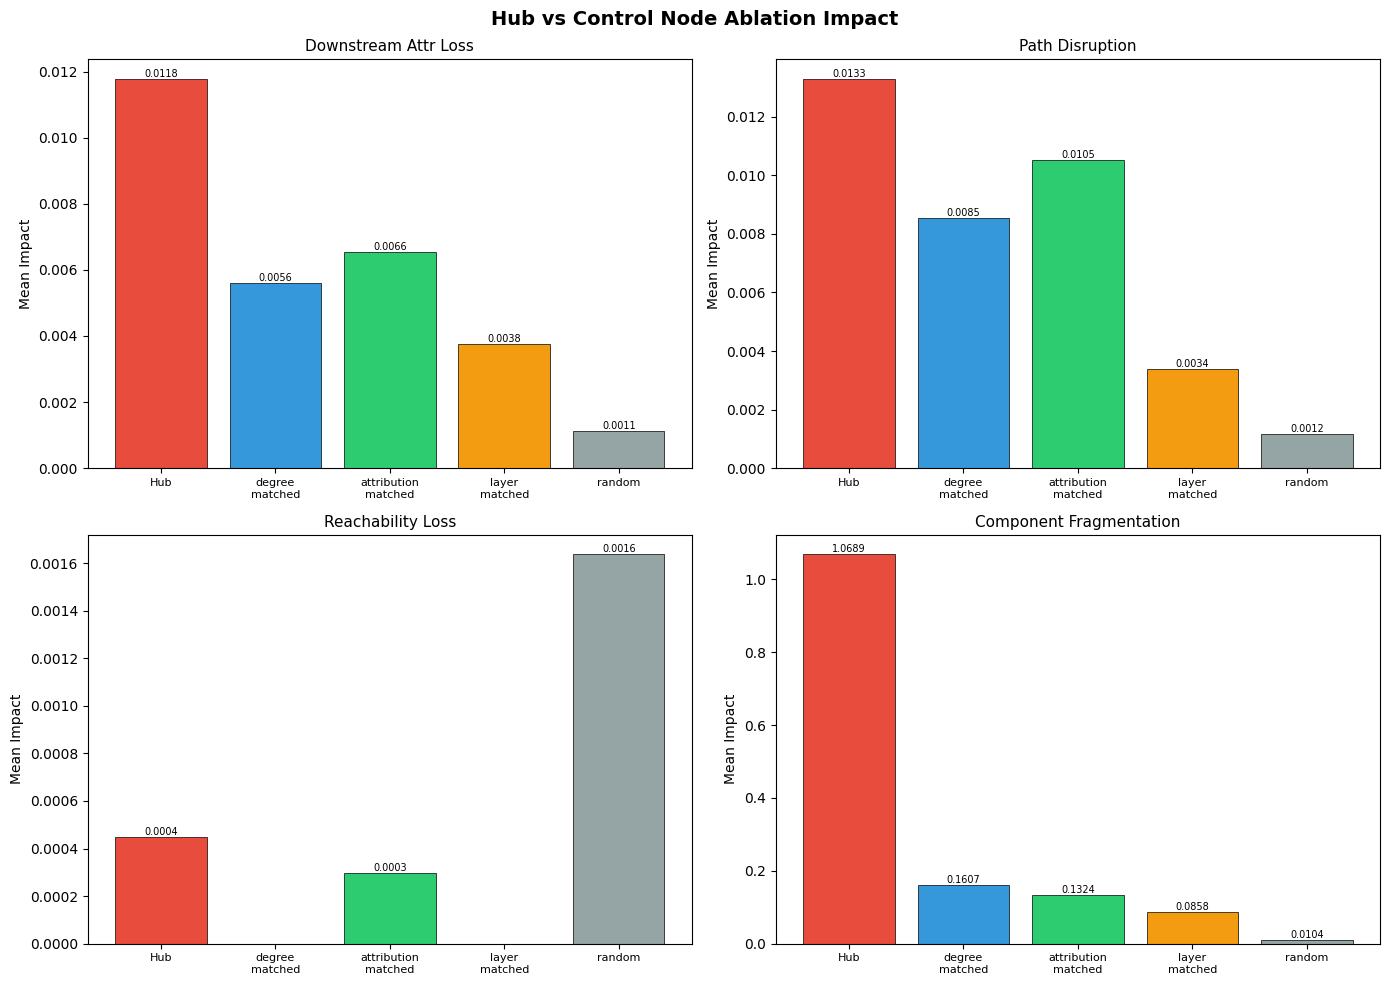

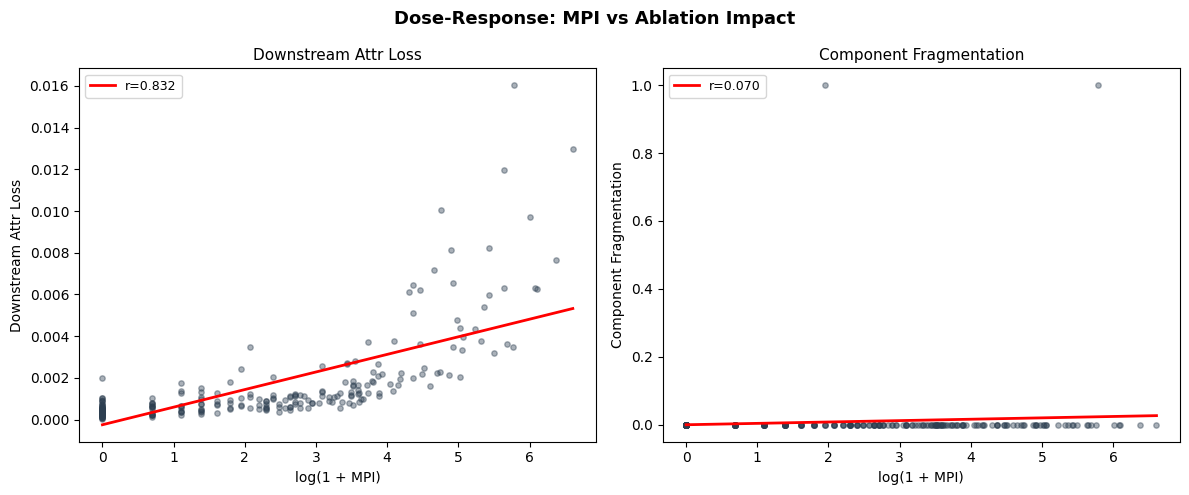

Done! Figures saved.


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Hub vs Control Node Ablation Impact", fontsize=14, fontweight="bold")

for ax_idx, metric in enumerate(METRICS):
    ax = axes[ax_idx // 2][ax_idx % 2]
    hub_vals = []
    ctrl_vals = {ct: [] for ct in CONTROL_TYPES}

    for p in all_matched_pairs:
        if p["metric"] == metric:
            hub_vals.append(p["hub_impact"])
            ctrl_vals[p["control_type"]].append(p["control_impact"])

    # Bar chart: mean impact for hub vs each control type
    labels = ["Hub"] + [ct.replace("_", "\n") for ct in CONTROL_TYPES]
    means = [np.mean(hub_vals) if hub_vals else 0]
    for ct in CONTROL_TYPES:
        means.append(np.mean(ctrl_vals[ct]) if ctrl_vals[ct] else 0)

    colors = ["#e74c3c"] + ["#3498db", "#2ecc71", "#f39c12", "#95a5a6"]
    bars = ax.bar(labels, means, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(metric.replace("_", " ").title(), fontsize=11)
    ax.set_ylabel("Mean Impact")
    ax.tick_params(axis='x', labelsize=8)

    # Add value labels on bars
    for bar, val in zip(bars, means):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{val:.4f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("ablation_impact.png", dpi=100, bbox_inches="tight")
plt.show()

# ---- Dose-Response Scatter ----
if all_dose:
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    fig2.suptitle("Dose-Response: MPI vs Ablation Impact", fontsize=13, fontweight="bold")

    log_mpis_arr = np.array([d["log_mpi"] for d in all_dose])

    for ax_idx, metric in enumerate(["downstream_attr_loss", "component_fragmentation"]):
        ax = axes2[ax_idx]
        impacts_arr = np.array([d[metric] for d in all_dose])
        ax.scatter(log_mpis_arr, impacts_arr, alpha=0.4, s=15, c="#2c3e50")
        ax.set_xlabel("log(1 + MPI)")
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_title(metric.replace("_", " ").title(), fontsize=11)

        # Add regression line
        dr = dose_response_results.get(metric, {})
        if "spearman_r" in dr:
            z = np.polyfit(log_mpis_arr, impacts_arr, 1)
            p = np.poly1d(z)
            x_line = np.linspace(log_mpis_arr.min(), log_mpis_arr.max(), 50)
            ax.plot(x_line, p(x_line), "r-", linewidth=2, label=f"r={dr['spearman_r']:.3f}")
            ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("dose_response.png", dpi=100, bbox_inches="tight")
    plt.show()

print("Done! Figures saved.")